<a href="https://colab.research.google.com/github/Ayush900-hp/ann-vs-cnn-image-classification/blob/main/ANN_vs_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
GPU available: True
GPU name: Tesla T4


In [ ]:
from google.colab import files
files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip -d data

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:04<00:00, 74.5MB/s]



In [5]:
!ls data

seg_pred  seg_test  seg_train


In [6]:
import os

for split in ["seg_train/seg_train", "seg_test/seg_test"]:
    path = f"data/{split}"
    print(path)
    for cls in sorted(os.listdir(path)):
        print("  ", cls, len(os.listdir(f"{path}/{cls}")))

data/seg_train/seg_train
   buildings 2191
   forest 2271
   glacier 2404
   mountain 2512
   sea 2274
   street 2382
data/seg_test/seg_test
   buildings 437
   forest 474
   glacier 553
   mountain 525
   sea 510
   street 501


In [7]:
import torch, time
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Resize 150x150, tensor mein convert (0-1), phir normalize (-1 se 1)
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_ds = datasets.ImageFolder("data/seg_train/seg_train", transform=transform)
val_ds   = datasets.ImageFolder("data/seg_test/seg_test",  transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)

print("Classes:", train_ds.classes)
print("Train images:", len(train_ds))
print("Val images:", len(val_ds))

x, y = next(iter(train_loader))
print("Batch shape:", x.shape)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train images: 14034
Val images: 3000
Batch shape: torch.Size([64, 3, 150, 150])


In [9]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                    # 3x150x150 -> 67500
            nn.Linear(3*150*150, 512),       # dense layer 1
            nn.ReLU(),
            nn.Linear(512, 256),             # dense layer 2
            nn.ReLU(),
            nn.Linear(256, 6)                # output: 6 classes
        )

    def forward(self, x):
        return self.net(x)

# Trainable parameters count karne ka function (comparison ke liye zaroori)
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

ann = ANN().to(device)
print(ann)
print("ANN trainable parameters:", count_params(ann))

ANN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=67500, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=6, bias=True)
  )
)
ANN trainable parameters: 34693382


In [10]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),     # 150 -> 75
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # 75 -> 37
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 37 -> 18
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                       # 128*18*18 = 41472
            nn.Dropout(0.5),                    # regularization
            nn.Linear(128*18*18, 128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 6)                   # output: 6 classes
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn = CNN().to(device)
print(cnn)
print("CNN trainable parameters:", count_params(cnn))

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=41472, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=6, bias=True)
  )
)
CNN trainable parameters: 5402566


In [11]:
def train_model(model, epochs=10, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_acc": []}

    start = time.time()
    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # ---- Validation ----
        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()

        acc = correct / len(val_ds)
        avg_loss = total_loss / len(train_loader)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(acc)
        print(f"Epoch {epoch+1}/{epochs} | loss: {avg_loss:.4f} | val_acc: {acc:.4f}")

    total_time = time.time() - start
    print(f"\nTotal training time: {total_time:.1f} seconds")
    return total_time, history

In [12]:
ann = ANN()
ann_time, ann_hist = train_model(ann, epochs=10)

Epoch 1/10 | loss: 1.5186 | val_acc: 0.5363
Epoch 2/10 | loss: 1.0599 | val_acc: 0.5790
Epoch 3/10 | loss: 0.9391 | val_acc: 0.5890
Epoch 4/10 | loss: 0.8196 | val_acc: 0.5843
Epoch 5/10 | loss: 0.7250 | val_acc: 0.6043
Epoch 6/10 | loss: 0.6322 | val_acc: 0.5910
Epoch 7/10 | loss: 0.5793 | val_acc: 0.6003
Epoch 8/10 | loss: 0.5203 | val_acc: 0.5987
Epoch 9/10 | loss: 0.4882 | val_acc: 0.6007
Epoch 10/10 | loss: 0.4159 | val_acc: 0.6073

Total training time: 176.9 seconds


In [13]:
cnn = CNN()
cnn_time, cnn_hist = train_model(cnn, epochs=10)

Epoch 1/10 | loss: 0.9644 | val_acc: 0.7307
Epoch 2/10 | loss: 0.6342 | val_acc: 0.7873
Epoch 3/10 | loss: 0.5022 | val_acc: 0.8100
Epoch 4/10 | loss: 0.4300 | val_acc: 0.8357
Epoch 5/10 | loss: 0.3473 | val_acc: 0.8343
Epoch 6/10 | loss: 0.2835 | val_acc: 0.8363
Epoch 7/10 | loss: 0.2406 | val_acc: 0.8307
Epoch 8/10 | loss: 0.1957 | val_acc: 0.8387
Epoch 9/10 | loss: 0.1588 | val_acc: 0.8317
Epoch 10/10 | loss: 0.1427 | val_acc: 0.8400

Total training time: 202.2 seconds


,Model,Training Time (s),Best Val Accuracy (%),Trainable Parameters
0,ANN,176.9,60.73,34693382
1,CNN,202.2,84.00,5402566


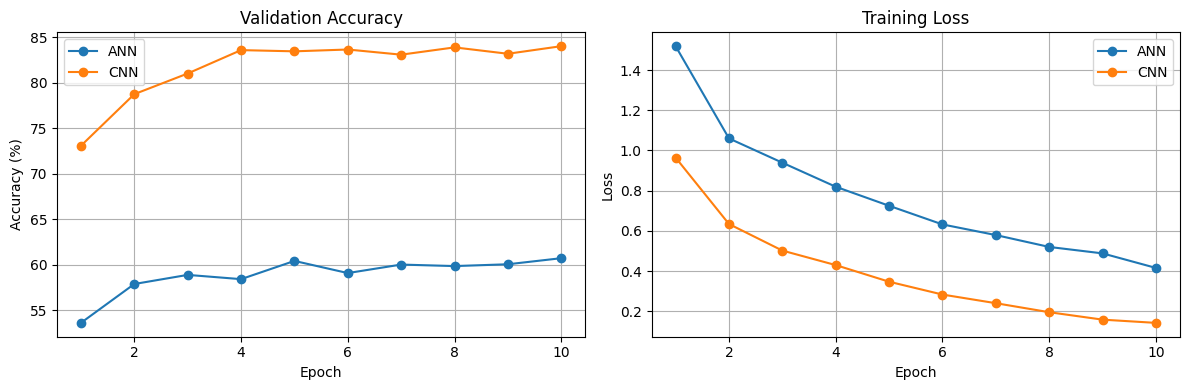

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- Comparison table ----
results = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Training Time (s)": [round(ann_time, 1), round(cnn_time, 1)],
    "Best Val Accuracy (%)": [round(max(ann_hist["val_acc"])*100, 2),
                              round(max(cnn_hist["val_acc"])*100, 2)],
    "Trainable Parameters": [count_params(ann), count_params(cnn)],
})
display(results)

# ---- Graphs ----
epochs = range(1, 11)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs, [a*100 for a in ann_hist["val_acc"]], marker="o", label="ANN")
ax[0].plot(epochs, [a*100 for a in cnn_hist["val_acc"]], marker="o", label="CNN")
ax[0].set_title("Validation Accuracy")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Accuracy (%)")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(epochs, ann_hist["train_loss"], marker="o", label="ANN")
ax[1].plot(epochs, cnn_hist["train_loss"], marker="o", label="CNN")
ax[1].set_title("Training Loss")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss")
ax[1].legend(); ax[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
import copy

def measure_inference(model, dev, n_batches=20, use_fp16=False, batch_size=64):
    m = copy.deepcopy(model).to(dev).eval()
    x = torch.randn(batch_size, 3, 150, 150).to(dev)

    def run():
        if use_fp16:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                m(x)
        else:
            m(x)

    with torch.no_grad():
        for _ in range(3):          # warm-up (pehle runs slow hote hain)
            run()
        if dev.type == "cuda":
            torch.cuda.synchronize()  # GPU ka kaam khatam hone tak ruko
        start = time.time()
        for _ in range(n_batches):
            run()
        if dev.type == "cuda":
            torch.cuda.synchronize()
        total = time.time() - start

    return total / (n_batches * batch_size) * 1000   # ms per image

cpu_ms  = measure_inference(cnn, torch.device("cpu"),  n_batches=5)
gpu_ms  = measure_inference(cnn, torch.device("cuda"), n_batches=20)
fp16_ms = measure_inference(cnn, torch.device("cuda"), n_batches=20, use_fp16=True)

speed = pd.DataFrame({
    "Setup": ["CPU (FP32)", "GPU / CUDA (FP32)", "GPU / CUDA (FP16)"],
    "ms per image": [round(cpu_ms, 3), round(gpu_ms, 3), round(fp16_ms, 3)],
    "Speedup vs CPU": [1.0, round(cpu_ms/gpu_ms, 1), round(cpu_ms/fp16_ms, 1)],
})
display(speed)

,Setup,ms per image,Speedup vs CPU
0,CPU (FP32),22.177,1.0
1,GPU / CUDA (FP32),0.317,70.1
2,GPU / CUDA (FP16),0.148,150.3


## Comparison Analysis: ANN vs CNN

| Metric | ANN | CNN |
|---|---|---|
| Final validation accuracy | 60.73% | 84.00% |
| Training time (10 epochs, T4 GPU) | 176.9 s | 202.2 s |
| Trainable parameters | 34,693,382 | 5,402,566 |

### Why did the CNN outperform the ANN?

1. **Spatial structure is preserved.** The ANN flattens each 150x150x3 image into a vector of 67,500 numbers, so it loses the information about which pixels are neighbours. The CNN keeps the 2D structure and looks at small local patches, which is where edges, textures and shapes live.

2. **Weight sharing gives parameter efficiency.** A convolution filter is reused across the whole image, so the CNN needs about 6.4x fewer parameters (5.4M vs 34.7M) yet reaches about 23 percentage points higher accuracy. Most of the ANN's parameters sit in its first dense layer (67,500 x 512), which is a very large and inefficient mapping.

3. **Hierarchical feature learning.** Early conv layers detect edges and colours, deeper layers combine them into patterns such as tree textures, ice, water or building outlines. A dense network has to learn all of this from raw pixels at once.

4. **Translation invariance through pooling.** Max-pooling makes the model less sensitive to the exact position of an object (for example a mountain slightly shifted in the frame), and it also reduces computation in later layers.

5. **Better generalisation.** The ANN's training loss fell from 1.52 to 0.42 while its validation accuracy stayed around 58-61%, a clear sign of overfitting (memorising instead of learning general features). The CNN also overfit a little (its validation accuracy flattened after epoch 4 while training loss kept falling), but dropout and weight sharing kept validation accuracy much higher.

**Trade-off:** the CNN took about 14% more training time per run because convolutions are more compute-intensive per parameter, but this is small compared to the accuracy gain.

## Bonus: Effect of pipeline optimisation on CNN inference speed

I measured CNN inference time per image (batch size 64):

| Setup | ms per image | Speedup vs CPU |
|---|---|---|
| CPU (FP32) | ___ | 1.0x |
| GPU / CUDA (FP32) | ___ | ___x |
| GPU / CUDA (FP16) | ___ | ___x |

**Discussion:**
- **CUDA:** convolutions are highly parallel (the same filter is applied at thousands of positions), so a GPU executes them much faster than a CPU.
- **Mixed precision (FP16):** halves memory traffic and can use Tensor Cores on NVIDIA GPUs, further reducing latency with a very small accuracy cost.
- **TensorRT** (not run here) would add further optimisations: layer fusion (e.g. Conv + ReLU in one kernel), INT8/FP16 quantisation, kernel auto-tuning for the specific GPU, and memory optimisation. Typically this gives an additional speedup over plain PyTorch CUDA inference, mainly useful for deployment and real-time applications.
- Trade-off: lower precision can slightly reduce accuracy, so the optimised model should be re-validated.